In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df_batter_offence  = pd.read_csv('data_csv/batter_offence.csv',  encoding='utf-8')
df_batter_offence2 = pd.read_csv('data_csv/batter_offence2.csv', encoding='utf-8')
df_pitcher         = pd.read_csv('data_csv/pitcher.csv',         encoding='utf-8')
df_team            = pd.read_csv('data_csv/team.csv',            encoding='utf-8')

# 투구 이닝 전처리
df_p = df_pitcher.copy().reset_index(drop=True)
for i, v in enumerate(df_p['inning']):
    parts = str(v).split()
    if len(parts) == 1:
        df_p.loc[i, 'inning'] = float(v)
    else:
        num, frac = parts
        a, b = frac.split('/')
        df_p.loc[i, 'inning'] = int(num) + int(a) / int(b)
df_p['inning'] = df_p['inning'].astype(float)
df_p['era']    = df_p['era'].astype(float)
df_p['kk']     = pd.to_numeric(df_p['kk'], errors='coerce')  # 삼진 추가

# 타자 전처리 — game_cnt > 72 (주전급 선수만)
df_b1 = df_batter_offence[df_batter_offence['game_cnt'] > 72].copy()
df_b1['avg']      = pd.to_numeric(df_b1['avg'],      errors='coerce')
df_b1['home_run'] = pd.to_numeric(df_b1['home_run'], errors='coerce')

# batter_offence2는 game_cnt 없으므로 주전 선수 이름 기준으로 필터
valid_players = df_b1['name'].unique()
df_b2 = df_batter_offence2[df_batter_offence2['name'].isin(valid_players)].copy()
df_b2['obp'] = pd.to_numeric(df_b2['obp'], errors='coerce')
df_b2['slg'] = pd.to_numeric(df_b2['slg'], errors='coerce')

# 팀별 평균 지표 계산
attack1 = df_b1.groupby('team')[['avg', 'home_run']].mean()
attack2 = df_b2.groupby('team')[['obp', 'slg']].mean()
pitch   = df_p[df_p['inning'] > 40].groupby('team')[['era', 'kk']].mean()  # kk 추가
rank    = df_team.groupby('team')[['ranking']].mean()

team_stats = attack1.join(attack2).join(pitch).join(rank)
print(team_stats.round(3))

        avg  home_run    obp    slg    era       kk  ranking
team                                                        
KIA   0.253     9.905  0.308  0.333  3.606  141.500      5.6
KT    0.251     6.311  0.311  0.334  3.757  143.455      3.6
LG    0.252     9.188  0.288  0.312  3.428  129.273      3.2
NC    0.247     6.825  0.301  0.321  3.128  190.000      5.2
SSG   0.253    10.421  0.310  0.339  3.782  147.375      3.0
두산    0.250     7.550  0.315  0.353  3.597  141.286      6.6
롯데    0.241     3.553  0.292  0.294  3.892  150.000      6.6
삼성    0.244     9.069  0.295  0.314  3.197  128.800      5.4
키움    0.241     6.000  0.292  0.291  3.265  158.875      8.0
한화    0.254     7.667  0.296  0.329  3.318  174.000      6.6


In [22]:
def normalize(series, invert=False):
    mean = series.mean()
    std  = series.std()
    norm = (series - mean) / (std * 2) * 50 + 50
    norm = norm.clip(0, 100)
    if invert:
        norm = 100 - norm
    return norm

team_stats['avg_n']  = normalize(team_stats['avg'])
team_stats['obp_n']  = normalize(team_stats['obp'])
team_stats['slg_n']  = normalize(team_stats['slg'])
team_stats['hr_n']   = normalize(team_stats['home_run'])
team_stats['era_n']  = normalize(team_stats['era'], invert=True)   # 낮을수록 좋음
team_stats['kk_n']   = normalize(team_stats['kk'])                 # 높을수록 좋음
team_stats['rank_n'] = normalize(team_stats['ranking'], invert=True)  # 낮을수록 좋음

print(team_stats[['avg_n','obp_n','slg_n','hr_n','era_n','kk_n','rank_n']].round(1))

      avg_n  obp_n  slg_n  hr_n  era_n   kk_n  rank_n
team                                                 
KIA    73.6   68.7   63.8  77.0   39.8   38.4    46.7
KT     60.6   77.3   65.4  34.0   25.7   40.9    76.7
LG     69.6   16.7   37.2  68.4   56.4   22.5    82.7
NC     41.7   49.6   49.3  40.1   84.5  100.0    52.7
SSG    71.2   74.4   71.4  83.2   23.3   46.0    85.7
두산     55.1   87.0   89.3  48.8   40.7   38.1    31.7
롯데     12.9   26.6   14.5   0.9   13.1   49.4    31.7
삼성     28.1   35.8   39.7  67.0   78.0   21.9    49.7
키움     11.2   27.1   10.3  30.2   71.7   60.9    10.7
한화     75.9   36.7   59.1  50.2   66.7   80.6    31.7


C:\Users\user\AppData\Local\Temp\ipykernel_18912\2587516839.py:52: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18912\2587516839.py:52: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18912\2587516839.py:52: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18912\2587516839.py:52: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\anaconda3\envs\git\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\envs\git\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATIO

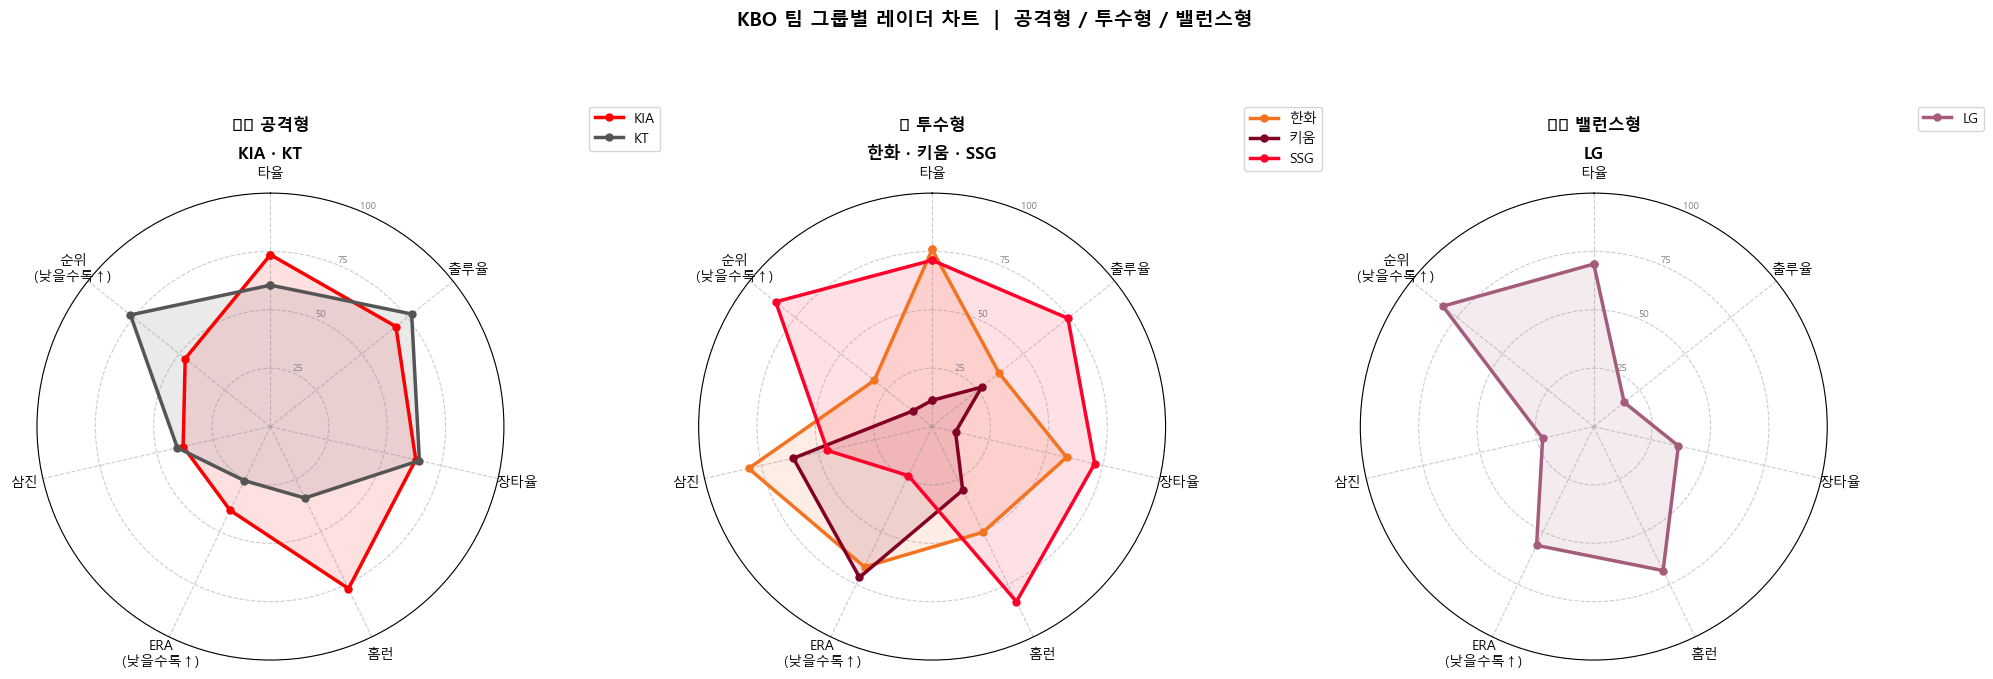

In [25]:
def draw_radar(ax, teams, colors, radar_data, stat_cols, stat_labels):
    N = len(stat_cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), stat_labels, fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], fontsize=7, color='gray')
    ax.grid(color='gray', linestyle='--', alpha=0.4)

    for team, color in zip(teams, colors):
        if team not in radar_data.index:
            continue
        values = radar_data.loc[team, stat_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2.5,
                marker='o', markersize=5, label=team)
        ax.fill(angles, values, color=color, alpha=0.12)

    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.2), fontsize=10)


# 3개 차트 모두 동일한 지표 순서 사용
stat_cols   = ['avg_n', 'obp_n', 'slg_n', 'hr_n', 'era_n', 'kk_n', 'rank_n']
stat_labels = ['타율', '출루율', '장타율', '홈런', 'ERA\n(낮을수록↑)', '삼진', '순위\n(낮을수록↑)']

groups = [
    ('⚔️ 공격형\nKIA · KT',
     ['KIA', 'KT'],
     ['#FA0000', '#555555']),

    ('🎯 투수형\n한화 · 키움 · SSG',
     ['한화', '키움', 'SSG'],
     ['#F37321', '#820024', '#FF002B']),

    ('⚖️ 밸런스형\nLG',
     ['LG'],
     ['#A55C7A']),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw=dict(polar=True))

for ax, (title, teams, colors) in zip(axes, groups):
    draw_radar(ax, teams, colors, team_stats, stat_cols, stat_labels)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=25, linespacing=1.8)

fig.suptitle('KBO 팀 그룹별 레이더 차트  |  공격형 / 투수형 / 밸런스형',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()